In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time,tracemalloc


In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [5]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [6]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [7]:
X = df[selected_features].values
y = df.iloc[:, 42].values


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# One-hot encoding label
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [10]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation

def to_onehot_softmax(y):
    y = np.asarray(y)
    if y.ndim == 1:
        # kasus label integer -> langsung jadikan one-hot
        num_classes = int(np.max(y)) + 1
        y_oh = to_categorical(y, num_classes=num_classes)
    elif y.ndim == 2:
        # (batch, C): asumsi sudah one-hot/prob; normalkan biar sum=1
        row_sum = y.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        y_oh = y / row_sum
    else:
        # contoh kasusmu: (batch, 2, 2) -> flatten ke (batch, 4) lalu ambil argmax -> class index
        y_flat = y.reshape(len(y), -1)
        class_idx = np.argmax(y_flat, axis=1)
        num_classes = y_flat.shape[1]
        y_oh = to_categorical(class_idx, num_classes=num_classes)
    return y_oh

y_train = to_onehot_softmax(y_train)
y_test  = to_onehot_softmax(y_test)



SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 20
NUM_CLASSES = y_train.shape[1]

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 20, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 20)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import time,tracemalloc
reference_set = X_train[:REF_COUNT]
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=128
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.9148 - loss: 0.2513 - val_accuracy: 0.9549 - val_loss: 0.1340
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9581 - loss: 0.1247 - val_accuracy: 0.9574 - val_loss: 0.1182
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9618 - loss: 0.1117 - val_accuracy: 0.9661 - val_loss: 0.1026
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9638 - loss: 0.1017 - val_accuracy: 0.9664 - val_loss: 0.0950
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9651 - loss: 0.0937 - val_accuracy: 0.9679 - val_loss: 0.0881
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9670 - loss: 0.0846 - val_accuracy: 0.9658 - val_loss: 0.0799
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9693 - loss: 0.0793 - val_accuracy: 0.9712 - val_loss: 0.0807
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9700 - loss: 0.0757 - 

In [12]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9688 - loss: 0.0738
Test Loss: 0.0738, Test Accuracy: 0.9688


In [13]:
print(f"\nTraining time: {end - start:.2f} seconds")
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")


Training time: 158.54 seconds
Memory usage: Current = 10.20 MB; Peak = 425.54 MB


In [14]:
y_pred = model.predict([X_test, reference_input_test])


788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


In [15]:
y_pred_binary = (y_pred > 0.5).astype(int)


In [16]:
y_true_binary = y_test.astype(int)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9688


In [17]:

y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)

if y_test.shape[1] > 1:
    y_test_binary = np.argmax(y_test, axis=1)
    y_pred_binary = np.argmax(y_pred_binary, axis=1)

precision = precision_score(y_test_binary, y_pred_binary, average='binary')
recall = recall_score(y_test_binary, y_pred_binary, average='binary')
f1 = f1_score(y_test_binary, y_pred_binary, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Precision: 0.9909
Recall: 0.9418
F1-Score: 0.9657
Specificity: 0.9688


In [18]:

eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()

print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")


pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()

print(f"Prediction time: {pred_end - pred_start:.2f} seconds")

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9688 - loss: 0.0738
Evaluation time: 2.59 seconds
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Prediction time: 2.39 seconds


In [19]:
#summary
print(f"Training time: {end - start:.2f} seconds")
print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
print(f"Prediction time: {pred_end - pred_start:.2f} seconds")
print(f"Total time: {(end - start) + (eval_end - eval_start) + (pred_end - pred_start):.2f} seconds")

Training time: 158.54 seconds
Evaluation time: 2.59 seconds
Prediction time: 2.39 seconds
Total time: 163.52 seconds


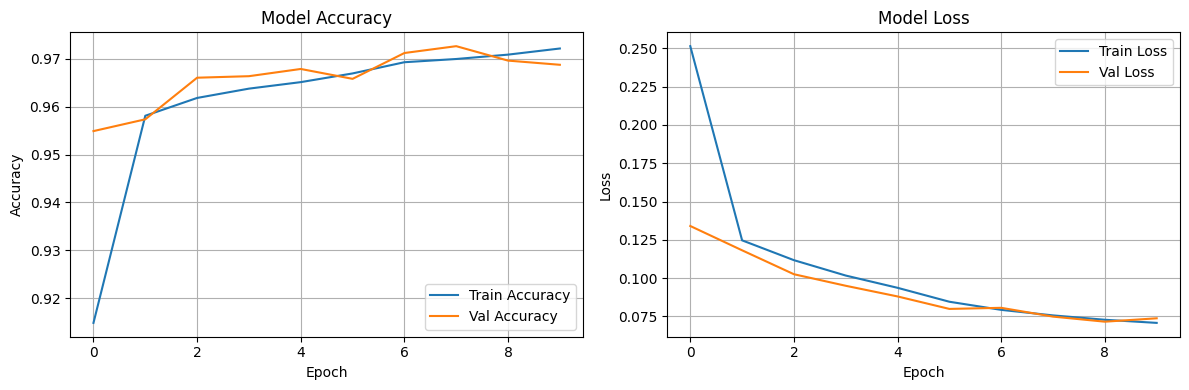

In [20]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()